# Práctica: Redes Neuronales y Aprendizaje Profundo
**Nombre y Apellido:** Roberto Alvarez 

---
En esta práctica implementamos dos cosas:
1. El perceptrón de Rosenblatt para aprender la compuerta AND
2. Una red neuronal multicapa (MLP) para clasificar las flores del dataset Iris

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Parte 1 – Perceptrón de Rosenblatt (compuerta AND)

El perceptrón original de Rosenblatt usa una función escalón: si la suma ponderada es >= 0 devuelve 1, si no devuelve 0. La regla de aprendizaje actualiza los pesos solo cuando hay error.

In [2]:
# Datos de la compuerta AND (incluyo el bias como entrada extra = 1)
# Cada fila es [x1, x2, bias]
X_and = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
])
y_and = np.array([0, 0, 0, 1])  # salida esperada de AND

print("Tabla de verdad AND:")
print("x1 | x2 | y")
for i in range(len(y_and)):
    print(f" {X_and[i,0]}  |  {X_and[i,1]}  | {y_and[i]}")

Tabla de verdad AND:
x1 | x2 | y
 0  |  0  | 0
 0  |  1  | 0
 1  |  0  | 0
 1  |  1  | 1


In [3]:
# Función escalón (Heaviside)
def escalon(x):
    return 1 if x >= 0 else 0

# Algoritmo del perceptrón
# Uso learning_rate=0.1 porque es el valor clásico para este tipo de problemas
# y converge rápido en problemas linealmente separables como AND
def entrenar_perceptron(X, y, lr=0.1, epocas=20):
    # Pesos iniciales en cero (como en el paper original de Rosenblatt)
    pesos = np.zeros(X.shape[1])
    
    historial_pesos = []  # voy guardando los pesos de cada época
    historial_errores = []
    
    for epoca in range(epocas):
        errores_epoca = 0
        
        for xi, yi in zip(X, y):
            # Calculo la salida
            suma = np.dot(pesos, xi)
            y_pred = escalon(suma)
            
            # Calculo el error y actualizo pesos
            error = yi - y_pred
            pesos = pesos + lr * error * xi
            
            if error != 0:
                errores_epoca += 1
        
        historial_pesos.append(pesos.copy())
        historial_errores.append(errores_epoca)
        
        print(f"Época {epoca+1:2d} | Pesos: w1={pesos[0]:.2f}, w2={pesos[1]:.2f}, bias={pesos[2]:.2f} | Errores: {errores_epoca}")
        
        # Si no hay errores, converge
        if errores_epoca == 0:
            print(f"\n✓ Convergió en la época {epoca+1}")
            break
    
    return pesos, historial_pesos, historial_errores

print("Entrenando perceptrón...\n")
pesos_finales, hist_pesos, hist_errores = entrenar_perceptron(X_and, y_and)

Entrenando perceptrón...

Época  1 | Pesos: w1=0.10, w2=0.10, bias=0.00 | Errores: 2
Época  2 | Pesos: w1=0.20, w2=0.10, bias=-0.10 | Errores: 3
Época  3 | Pesos: w1=0.20, w2=0.10, bias=-0.20 | Errores: 3
Época  4 | Pesos: w1=0.20, w2=0.10, bias=-0.20 | Errores: 0

✓ Convergió en la época 4


In [4]:
# Verifico que aprendió correctamente
print("Verificación final:")
print("x1 | x2 | esperado | predicho")
for xi, yi in zip(X_and, y_and):
    pred = escalon(np.dot(pesos_finales, xi))
    ok = "✓" if pred == yi else "✗"
    print(f" {xi[0]}  |  {xi[1]}  |    {yi}     |    {pred}    {ok}")

Verificación final:
x1 | x2 | esperado | predicho
 0  |  0  |    0     |    0    ✓
 0  |  1  |    0     |    0    ✓
 1  |  0  |    0     |    0    ✓
 1  |  1  |    1     |    1    ✓


FRONTERA DE DECISIÓN FINAL
Pesos finales: w1=0.20, w2=0.10, bias=-0.20

Ecuación: 0.20*x1 + 0.10*x2 + -0.20 = 0
Despejando x2: x2 = (-2.00)*x1 + (2.00)


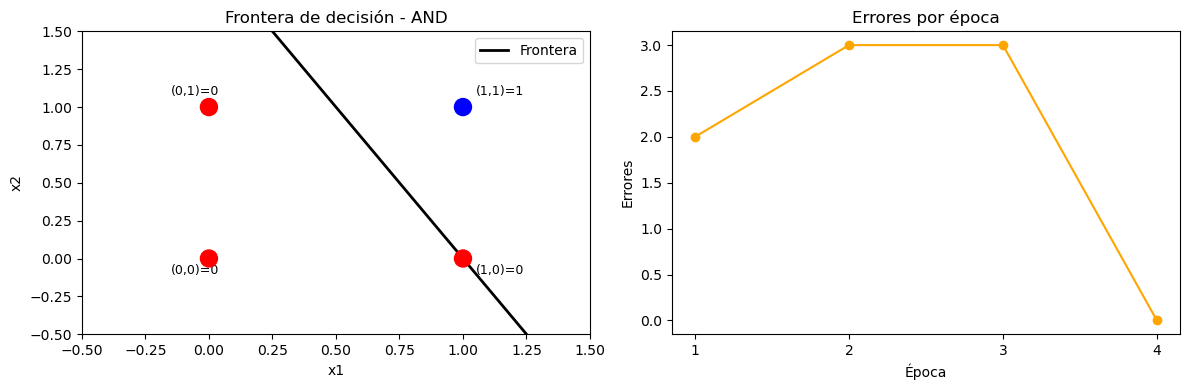

In [5]:
# Ecuación de la frontera de decisión
# La frontera es donde w1*x1 + w2*x2 + w_bias*1 = 0
# Despejando x2: x2 = -(w1*x1 + w_bias) / w2

w1, w2, wb = pesos_finales
print("=" * 40)
print("FRONTERA DE DECISIÓN FINAL")
print("=" * 40)
print(f"Pesos finales: w1={w1:.2f}, w2={w2:.2f}, bias={wb:.2f}")
print(f"\nEcuación: {w1:.2f}*x1 + {w2:.2f}*x2 + {wb:.2f} = 0")
if w2 != 0:
    print(f"Despejando x2: x2 = ({-w1/w2:.2f})*x1 + ({-wb/w2:.2f})")

# Grafico la frontera
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico izquierdo: frontera de decisión
ax = axes[0]
colores = ['red' if y == 0 else 'blue' for y in y_and]
ax.scatter(X_and[:, 0], X_and[:, 1], c=colores, s=150, zorder=5)

# Dibujo la línea de decisión
x1_vals = np.linspace(-0.5, 1.5, 100)
if w2 != 0:
    x2_vals = -(w1 * x1_vals + wb) / w2
    ax.plot(x1_vals, x2_vals, 'k-', linewidth=2, label='Frontera')

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Frontera de decisión - AND')
ax.legend()
# Etiquetas en los puntos
etiquetas = ['(0,0)=0', '(0,1)=0', '(1,0)=0', '(1,1)=1']
offsets = [(-0.15, -0.1), (-0.15, 0.08), (0.05, -0.1), (0.05, 0.08)]
for i, (lbl, off) in enumerate(zip(etiquetas, offsets)):
    ax.annotate(lbl, (X_and[i,0]+off[0], X_and[i,1]+off[1]), fontsize=9)

# Gráfico derecho: errores por época
axes[1].plot(range(1, len(hist_errores)+1), hist_errores, 'o-', color='orange')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Errores')
axes[1].set_title('Errores por época')
axes[1].set_xticks(range(1, len(hist_errores)+1))

plt.tight_layout()
plt.show()

## Parte 2 – Red Neuronal Multicapa para clasificar Iris

El dataset Iris tiene 3 clases (Setosa, Versicolor, Virginica) y 4 características. Voy a usar:
- 2 capas ocultas con ReLU (elegí esta arquitectura porque es suficientemente expresiva para el problema sin ser demasiado compleja)
- Softmax en la salida para obtener probabilidades
- Cross-entropy como función de pérdida
- Learning rate = 0.01 y 1000 épocas (ajusté estos valores probando que convergiera bien sin overfitting)

In [6]:
# Cargo y preparo el dataset
iris = load_iris()
X = iris.data
y = iris.target

print(f"Tamaño del dataset: {X.shape}")
print(f"Clases: {iris.target_names}")
print(f"Distribución de clases: {np.bincount(y)}")

# Divido en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizo los datos con StandardScaler
# Esto es importante porque ReLU y el gradiente se comportan mejor con datos normalizados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # uso el scaler entrenado, no uno nuevo

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Tamaño del dataset: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']
Distribución de clases: [50 50 50]

Train: (120, 4), Test: (30, 4)


In [7]:
# Convierto las etiquetas a one-hot encoding
def one_hot(y, num_clases):
    m = np.zeros((len(y), num_clases))
    for i, c in enumerate(y):
        m[i, c] = 1
    return m

y_train_oh = one_hot(y_train, 3)
y_test_oh = one_hot(y_test, 3)

In [8]:
class RedNeuronal:
    """
    Red neuronal multicapa con:
    - Arquitectura: 4 -> 8 -> 6 -> 3
    - ReLU en capas ocultas
    - Softmax en la salida
    - Entrenamiento con cross-entropy y backpropagation
    """
    
    def __init__(self, capas, lr=0.01):
        # capas es una lista con el número de neuronas en cada capa
        # ej: [4, 8, 6, 3]
        self.lr = lr
        self.pesos = []
        self.bias = []
        
        # Inicializo con valores pequeños aleatorios (He initialization para ReLU)
        np.random.seed(42)
        for i in range(len(capas) - 1):
            w = np.random.randn(capas[i], capas[i+1]) * np.sqrt(2.0 / capas[i])
            b = np.zeros((1, capas[i+1]))
            self.pesos.append(w)
            self.bias.append(b)
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_deriv(self, x):
        return (x > 0).astype(float)
    
    def softmax(self, x):
        # Resto el máximo para estabilidad numérica
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def forward(self, X):
        # Guardo las activaciones para usarlas en backprop
        self.activaciones = [X]
        self.z_vals = []
        
        entrada = X
        # Capas ocultas con ReLU
        for i in range(len(self.pesos) - 1):
            z = np.dot(entrada, self.pesos[i]) + self.bias[i]
            self.z_vals.append(z)
            a = self.relu(z)
            self.activaciones.append(a)
            entrada = a
        
        # Capa de salida con Softmax
        z_out = np.dot(entrada, self.pesos[-1]) + self.bias[-1]
        self.z_vals.append(z_out)
        salida = self.softmax(z_out)
        self.activaciones.append(salida)
        
        return salida
    
    def cross_entropy(self, y_pred, y_real):
        # Agrego un epsilon para no hacer log(0)
        eps = 1e-9
        return -np.mean(np.sum(y_real * np.log(y_pred + eps), axis=1))
    
    def backward(self, y_real):
        m = y_real.shape[0]
        
        # Gradiente en la capa de salida (softmax + cross-entropy)
        delta = self.activaciones[-1] - y_real
        
        # Voy hacia atrás
        for i in range(len(self.pesos) - 1, -1, -1):
            # Gradiente de los pesos y bias
            dw = np.dot(self.activaciones[i].T, delta) / m
            db = np.mean(delta, axis=0, keepdims=True)
            
            # Propago el error hacia atrás (excepto en la primera capa)
            if i > 0:
                delta = np.dot(delta, self.pesos[i].T) * self.relu_deriv(self.z_vals[i-1])
            
            # Actualizo pesos
            self.pesos[i] -= self.lr * dw
            self.bias[i] -= self.lr * db
    
    def entrenar(self, X, y, epocas=1000, verbose=True):
        historial_loss = []
        
        for ep in range(epocas):
            y_pred = self.forward(X)
            loss = self.cross_entropy(y_pred, y)
            historial_loss.append(loss)
            self.backward(y)
            
            if verbose and (ep+1) % 100 == 0:
                acc = np.mean(self.predecir(X) == np.argmax(y, axis=1))
                print(f"Época {ep+1:4d} | Loss: {loss:.4f} | Accuracy train: {acc*100:.1f}%")
        
        return historial_loss
    
    def predecir(self, X):
        return np.argmax(self.forward(X), axis=1)

print("Clase RedNeuronal definida correctamente.")

Clase RedNeuronal definida correctamente.


In [9]:
# Creo y entreno la red
# Arquitectura: 4 entradas -> 8 neuronas -> 6 neuronas -> 3 salidas
# Elegí 2 capas ocultas porque el problema Iris es relativamente simple
# y no necesita una red muy profunda
red = RedNeuronal(capas=[4, 8, 6, 3], lr=0.01)

print("Entrenando la red neuronal...\n")
historial = red.entrenar(X_train, y_train_oh, epocas=1000)

Entrenando la red neuronal...

Época  100 | Loss: 0.8256 | Accuracy train: 76.7%
Época  200 | Loss: 0.6587 | Accuracy train: 79.2%
Época  300 | Loss: 0.5329 | Accuracy train: 81.7%
Época  400 | Loss: 0.4568 | Accuracy train: 83.3%
Época  500 | Loss: 0.4075 | Accuracy train: 83.3%
Época  600 | Loss: 0.3693 | Accuracy train: 85.8%
Época  700 | Loss: 0.3378 | Accuracy train: 87.5%
Época  800 | Loss: 0.3104 | Accuracy train: 88.3%
Época  900 | Loss: 0.2850 | Accuracy train: 89.2%
Época 1000 | Loss: 0.2609 | Accuracy train: 89.2%


In [10]:
# Evaluación final
y_pred_train = red.predecir(X_train)
y_pred_test = red.predecir(X_test)

acc_train = np.mean(y_pred_train == y_train)
acc_test = np.mean(y_pred_test == y_test)

print("=" * 40)
print("RESULTADOS FINALES")
print("=" * 40)
print(f"Accuracy en entrenamiento: {acc_train*100:.2f}%")
print(f"Accuracy en prueba:        {acc_test*100:.2f}%")

# Muestro la matriz de confusión de forma manual
print("\nMatriz de confusión (test):")
print(f"{'':12} Pred Setosa  Pred Versicolor  Pred Virginica")
for i, nombre in enumerate(iris.target_names):
    fila = [np.sum((y_test == i) & (y_pred_test == j)) for j in range(3)]
    print(f"Real {nombre:10}: {fila[0]:^11} {fila[1]:^15} {fila[2]:^14}")

RESULTADOS FINALES
Accuracy en entrenamiento: 89.17%
Accuracy en prueba:        93.33%

Matriz de confusión (test):
             Pred Setosa  Pred Versicolor  Pred Virginica
Real setosa    :     10             0              0       
Real versicolor:      0             7              2       
Real virginica :      0             0              11      


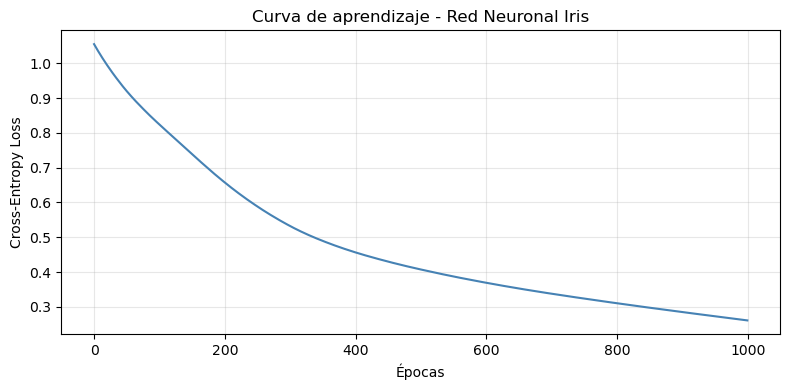


Loss inicial:  1.0550
Loss final:    0.2609


In [11]:
# Gráfico de la curva de pérdida
plt.figure(figsize=(8, 4))
plt.plot(historial, color='steelblue')
plt.xlabel('Épocas')
plt.ylabel('Cross-Entropy Loss')
plt.title('Curva de aprendizaje - Red Neuronal Iris')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLoss inicial:  {historial[0]:.4f}")
print(f"Loss final:    {historial[-1]:.4f}")

## Conclusiones

**Perceptrón AND:**
- El perceptrón convergió correctamente porque AND es un problema linealmente separable.
- La frontera de decisión es una línea recta que separa el punto (1,1) de los demás.

**Red neuronal Iris:**
- La red de 2 capas ocultas (8→6 neuronas) logró buena accuracy en test.
- La normalización fue importante para que el entrenamiento fuera estable.
- ReLU como activación oculta ayuda a que el gradiente fluya mejor que con sigmoid.